# Atera – Spatial data with single-cell resolution

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/earmingol/scCellFie/blob/main/docs/source/notebooks/atera_analysis.ipynb)

In this tutorial, we will explore how scCellFie can be run on [the latest spatial technology from 10X Genomics (Atera)](https://www.10xgenomics.com/platforms/atera). This tutorial should be also compatible with other spatial technologies with single-cell resolution covering the whole transcriptome such as [Visium HD](https://www.10xgenomics.com/platforms/visium/product-family).

Here, we will use the preview data published by 10X Genomics for [Breast Cancer](https://www.10xgenomics.com/datasets/atera-wta-ffpe-human-breast-cancer).

## This tutorial includes following steps:

* [Loading libraries](#loading-libraries)
* [Loading Atera data](#loading-atera-data)
* [Loading cell polygons](#loading-cell-polygons)
* [QC metrics](#qc-metrics)
* [Preprocessing](#preprocessing)
* [scCellFie Data preparation](#sccellfie-data-preparation)
* [Run scCellFie](#run-sccellfie)
* [Visualizations](#visualizations)

## Loading libraries <a class="anchor" id="loading-libraries"></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sccellfie
from sccellfie.io import read_xenium, load_xenium_segmentation
from sccellfie.datasets import load_sccellfie_database
from sccellfie.expression.thresholds import get_sccellfie_dataset_threshold
from sccellfie.reports import generate_completeness_report
from sccellfie.plotting import plot_segmentation

import scanpy as sc

/Users/eg22/miniforge3/envs/single_cell/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In addition, we set up the folder where the Atera data bundle (output of Xenium Ranger) is located:

In [2]:
DATA_DIR = "/Users/eg22/RNAseq-Data/Atera-FFPE-Breast-Cancer/"

## Loading Atera data <a class="anchor" id="loading-atera-data"></a>

The bundle is expected to contain at minimum `cell_feature_matrix.h5`, `cells.csv.gz`, and `cell_boundaries.parquet`.

`read_xenium` reads the cell-feature matrix, joins centroids from `cells.csv.gz`, and (when present) attaches `analysis/clustering/gene_expression_graphclust/clusters.csv` as `adata.obs['cluster']`. Centroids land in `adata.obsm['X_spatial']` — the scCellFie convention.

In [3]:
adata = read_xenium(DATA_DIR, segmentation="cell")
adata

Note: /Users/eg22/RNAseq-Data/Atera-FFPE-Breast-Cancer/analysis/clustering/gene_expression_graphclust/clusters.csv not found, skipping cluster attachment.


AnnData object with n_obs × n_vars = 170057 × 18028
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'X_spatial'

## Loading cell polygons <a class="anchor" id="loading-cell-polygons"></a>

We then load the cell segmentation resulting from running Xenium Ranger. Here, we apply the function `load_xenium_segmentation`, which returns a `{cell_id: shapely.Polygon}` dict ready for the function `plot_segmentation` in scCellFie v0.6.0. The cell IDs must match `adata.obs_names`, so in case you changed them in your data, you will need to adjust the IDs in the keys of this dictionary to match your data.

In [4]:
seg = load_xenium_segmentation(f"{DATA_DIR}/cell_boundaries.parquet", output="dict")
print(f"Loaded {len(seg)} polygons")

Loaded 170057 polygons


## QC Metrics <a class="anchor" id="qc-metrics"></a>

We use the scanpy functions to evaluate different metrics of the Atera data:

In [5]:
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


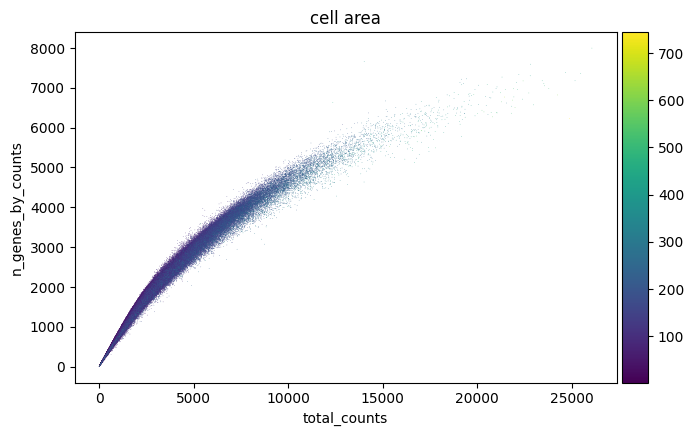

In [6]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="cell_area")

We can also render every cell as its segmentation polygon, coloured by the `total_counts` metric. For this purposes, scCellFie includes a convinient `plot_segmentation` function.

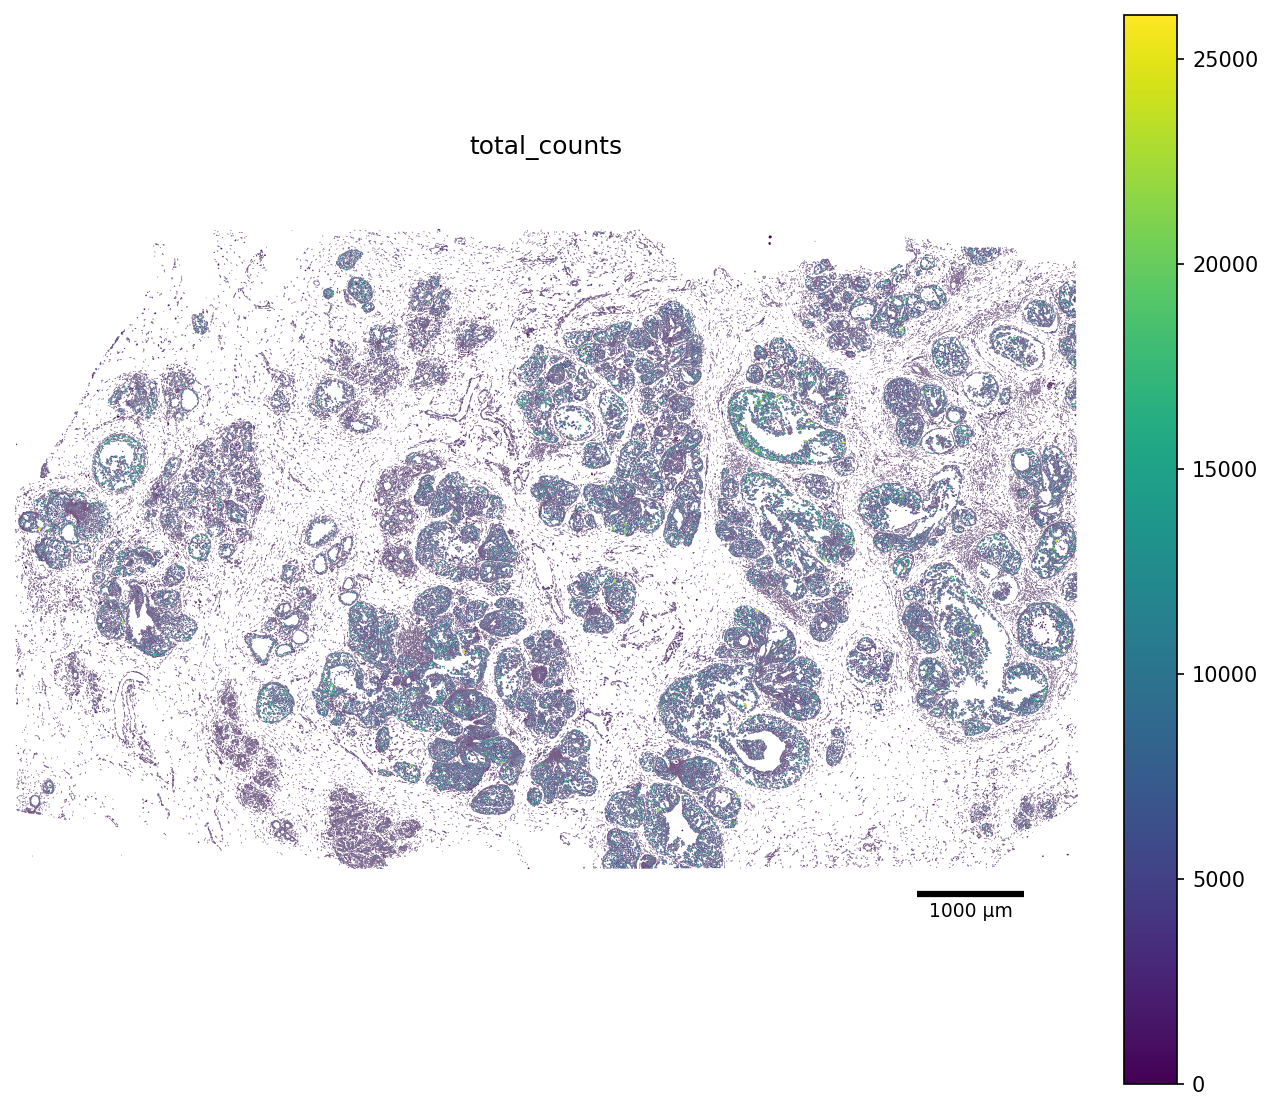

In [7]:
color_by = "total_counts"

fig, ax = plot_segmentation(
    adata,
    segmentation=seg,
    color_by=color_by,
    figsize=(10, 10),
    scalebar_kwargs={"units": "µm"},
)

Additionally, we can crop our visualization window by picking a rectangular region of the slide. The window is in the same coordinate units as `adata.obsm['X_spatial']` (microns for Xenium).

Adjust `crop` to a region of interest. The window below displays a default 1500-µm by 2000-µm selection box, with X-axis limits of 8500-10000 and Y-axis limits of 1500-3500.


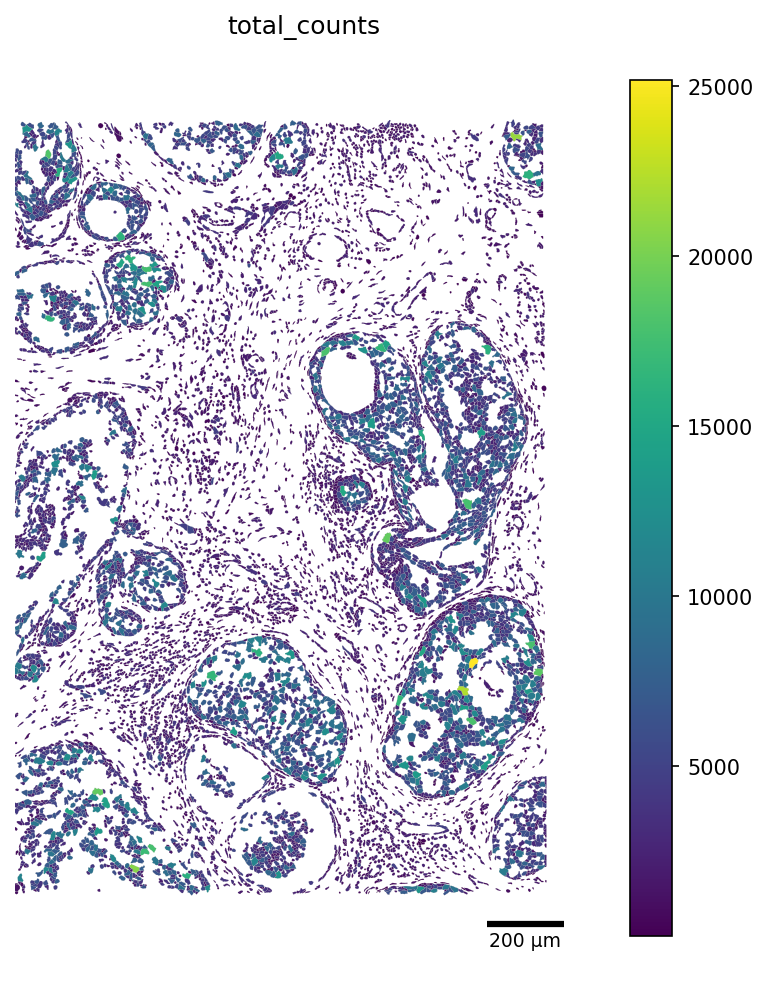

In [8]:
crop_window = (8500, 1500, 10000, 3500)

fig, ax = plot_segmentation(
    adata,
    segmentation=seg,
    color_by=color_by,
    crop=crop_window,
    figsize=(8, 8),
    scalebar_kwargs={"units": "µm"},
)

## Preprocessing <a class="anchor" id="preprocessing"></a>

Now that we have a general idea of our data, we can apply some basic filtering.

In [9]:
min_counts_cell = 100
min_genes = 10
min_counts_gene = 20
min_cells = 20
target_sum = 10000

In [10]:
sc.pp.filter_cells(adata, min_counts=min_counts_cell)
sc.pp.filter_cells(adata, min_genes=min_genes)

sc.pp.filter_genes(adata, min_counts=min_counts_gene)
sc.pp.filter_genes(adata, min_cells=min_cells)

Then, normalize and log-transform the data.

In [11]:
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=target_sum, inplace=True)
sc.pp.log1p(adata)

## scCellFie Data preparation <a class="anchor" id="sccellfie-data-preparation"></a>

### Data completeness

Before running scCellFie, we need to understand how complete is our data in term of genes that are covered in the DB of metabolic tasks used in the analysis.

In this case, scCellFie conveniently incorporates a `generate_completeness_report` functions that answers two questions:

- **Dataset-level**: which genes / reactions / tasks from the metabolic database are even measurable on this assay (i.e. present in `adata.var_names`)?
- **Cell-level**: per cell, how complete is each task given the genes that are present *and* expressed (>0)?

The dataset-level answer is computed on the full slide.

We first load the DB we will use in the analysis, in this case we use the one already included in scCellFie:

In [12]:
db = load_sccellfie_database(organism='human')
gpr_strings = db["rxn_info"].set_index("Reaction")["GPR-symbol"].to_dict()

Then, we generate the report:

In [13]:
report = generate_completeness_report(
    adata,
    gpr_source=gpr_strings,
    task_by_rxn=db["task_by_rxn"],
    metric="fraction_zeroed",
    threshold=1.0,
    layer='counts',
    write_to_obs=True,
)

This function generates the following reports:

**Dataset-level views**
- report["dataset"]["task_completeness"]      # which tasks are well-supported?
- report["dataset"]["reaction_completeness"]  # which reactions specifically?
- report["dataset"]["overall_summary"]        # one-line headline numbers

**Cell-level views**
- report["cell"]["per_cell"]                  # one score per cell (essential + all)
- report["cell"]["matrix_essential"]          # includes info about essential genes
- report["cell"]["matrix_all"]                # includes info about all genes in the DB

We can check how the **dataset-level completeness** look like:

In [14]:
overall = report["dataset"]["overall_summary"]
overall

,n_tasks_total,n_tasks_fully_covered_essential,n_tasks_fully_covered_all,n_tasks_compromised_essential,n_tasks_compromised_all,mean_task_impact_weighted_essential,mean_task_impact_weighted_all,mean_task_fraction_present_essential,mean_task_fraction_present_all,n_reactions_total,n_reactions_fully_covered_essential,n_reactions_fully_covered_all,n_genes_in_db_total,n_genes_in_db_present_in_adata,fraction_db_genes_present
0,218,216,139,2,60,0.990826,0.93844,0.994393,0.957514,787,755,737,931,879,0.944146


The columns of this dataframe are:

| Column | Meaning |
|---|---|
| `n_tasks_total` | Number of tasks in `task_by_rxn` (DB). |
| `n_tasks_fully_covered_essential` | Tasks where `fraction_present_essential == 1.0`. |
| `n_tasks_fully_covered_all` | Tasks where `fraction_present_all == 1.0`. |
| `n_tasks_compromised_essential` | Tasks where `impact_weighted_completeness_essential < 1.0`. |
| `n_tasks_compromised_all` | Tasks where `impact_weighted_completeness_all < 1.0`. |
| `mean_task_impact_weighted_essential` | Mean of per-task essential impact-weighted completeness. |
| `mean_task_impact_weighted_all` | Mean of per-task all-scope impact-weighted completeness. |
| `mean_task_fraction_present_essential` | Mean of per-task `fraction_present_essential`. |
| `mean_task_fraction_present_all` | Mean of per-task `fraction_present_all`. |
| `n_reactions_total` | Number of reactions. |
| `n_reactions_fully_covered_essential` | Reactions where `fraction_present_essential == 1.0`. |
| `n_reactions_fully_covered_all` | Reactions where `fraction_present_all == 1.0`. |
| `n_genes_in_db_total` | Distinct genes across the whole GPR database. |
| `n_genes_in_db_present_in_adata` | Of those, how many your assay measures. |
| `fraction_db_genes_present` | Ratio of the previous two (1.0 if database is empty). |

In [15]:
# Top tasks ranked by impact-weighted completeness over essential genes
task_completeness = report["dataset"]["task_completeness"]
task_completeness.sort_values("impact_weighted_completeness_essential", 
                              ascending=False).head(15)

,n_genes_essential,n_present_essential,n_missing_essential,fraction_present_essential,impact_weighted_completeness_essential,total_impact_missing_essential,missing_genes_essential,n_genes_all,n_present_all,n_missing_all,fraction_present_all,impact_weighted_completeness_all,total_impact_missing_all,missing_genes_all
Task,,,,,,,,,,,,,,
(R)-3-Hydroxybutanoate synthesis,0,0,0,1.0,1.0,0.0,,29,29,0,1.000000,1.000000,0.000000,
Sialylation (addition of sialic acid),0,0,0,1.0,1.0,0.0,,2,2,0,1.000000,1.000000,0.000000,
Presence of the thioredoxin system through the thioredoxin reductase activity,1,1,0,1.0,1.0,0.0,,1,1,0,1.000000,1.000000,0.000000,
Proline degradation,0,0,0,1.0,1.0,0.0,,94,91,3,0.968085,0.955882,0.044118,PAICS;SLC25A6;TALDO1
Proline synthesis,0,0,0,1.0,1.0,0.0,,28,28,0,1.000000,1.000000,0.000000,
Proteasome degradation,0,0,0,1.0,1.0,0.0,,37,35,2,0.945946,0.333333,0.666667,PSMA5;PSMD7
Pyridoxal-phosphate synthesis,1,1,0,1.0,1.0,0.0,,1,1,0,1.000000,1.000000,0.000000,
Reactive oxygen species detoxification (H2O2 to H2O),1,1,0,1.0,1.0,0.0,,1,1,0,1.000000,1.000000,0.000000,
Recognition of misfolded protein,0,0,0,1.0,1.0,0.0,,11,11,0,1.000000,1.000000,0.000000,


Task completeness and reaction completeness dataframes include similar information of each of them:

| Column | Meaning |
|---|---|
| `n_genes_essential` | Number of essential genes for this task. |
| `n_present_essential` | Of those, how many are in `adata.var_names`. |
| `n_missing_essential` | How many are absent from `adata.var_names`. |
| `fraction_present_essential` | `n_present_essential / n_genes_essential` (1.0 if empty). |
| `total_impact_missing_essential` | Raw sum of `rel_change` ablation impacts of the missing essential genes; can exceed 1.0. |
| `impact_weighted_completeness_essential` | `1 − clip(total_impact_missing_essential, 0, 1)`. Headline score. |
| `missing_genes_essential` | `;`-joined list of missing essential gene symbols. |
| `n_genes_all` | Total number of genes appearing in any reaction of this task. |
| `n_present_all` | Of those, how many are in `adata.var_names`. |
| `n_missing_all` | How many are absent from `adata.var_names`. |
| `fraction_present_all` | `n_present_all / n_genes_all` (1.0 if empty). |
| `total_impact_missing_all` | Raw sum of `rel_change` impacts over missing all-scope genes. |
| `impact_weighted_completeness_all` | `1 − clip(total_impact_missing_all, 0, 1)`. |
| `missing_genes_all` | `;`-joined list of missing all-scope gene symbols. |

Similarly, we can check the completeness at a **cell-level**. First we inspect the essential genes:

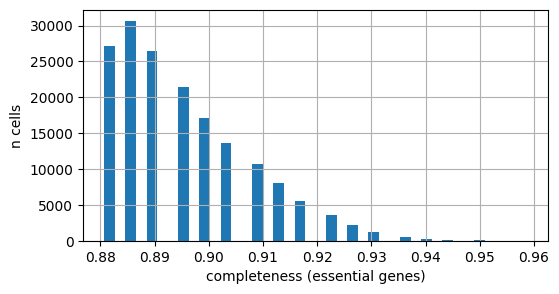

In [16]:
# Distribution of per-cell completeness (essential-gene scope) across the slide
fig, ax = plt.subplots(figsize=(6, 3))
adata.obs["completeness_essential"].hist(bins=40, ax=ax)
ax.set_xlabel("completeness (essential genes)")
ax.set_ylabel("n cells")
plt.show()


And all the genes in the DB:

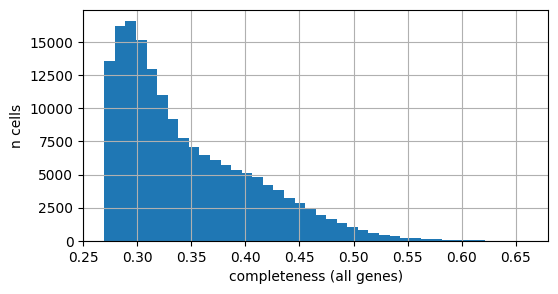

In [17]:
# Distribution of per-cell completeness (all-gene scope) across the slide
fig, ax = plt.subplots(figsize=(6, 3))
adata.obs["completeness_all"].hist(bins=40, ax=ax)
ax.set_xlabel("completeness (all genes)")
ax.set_ylabel("n cells")
plt.show()


### Gene expression thresholds for computing metabolic scores

A core step of the scCellFie's workflow is using threshold values to determine whether a metabolic gene may be active or not. As indicated in the [scCellFie publication](https://doi.org/10.1101/2025.05.09.653038), we can compute the threshold of each metabolic gene by using gene expression at an atlas scale (e.g. the human cell atlas). However, the Atera technology is quite recent so there is no atlas-scale data available, covering the full difersity of cells in the human body. Therefore, the full range of Atera-level expression for each of the metabolic genes is not available.

For this reason, here we rely only on the gene expression levels found within the slide. Normally, we compute a threshold value as the mean value of the non-zero CP10K expression levels, clipped to the 25th and 75th expression percentiles across all metabolic genes as lower and upper boundaries. In this case, we will adapt this approach to make each activity to be meaningful relatevely to cells within the slide:

To compute the thresholds, we can use the `get_sccellfie_dataset_threshold` function, which streams the AnnData in chunks and computes a per-gene threshold using  by default the same rule as in the scCellFie manuscript (`clip(nonzero_mean, P25, P75)`). It returns a single-column DataFrame consumable by `run_sccellfie_pipeline` via `threshold_key`.

This is run on within the slide so the percentiles reflect the slide's true expression distribution. Here, instead of using as boundaries the 25th and 75th percentiles, we use the 10th and 40th percentiles as the lower and upper boundaries.

<div class="alert alert-info">
<b>Note!</b>

You can personalize the thresholds as you prefer to compare activities within the slide. It is important to consider that this example may misrepresent the activity of some tasks as the threshold values are computed in a dataset-wise manner rather than an atlas-wise manner, which may lead to overall low/high activity of some of the tasks when they should behave differently.`

</div>

In [18]:
thresholds = get_sccellfie_dataset_threshold(
    adata,
    organism='human',
    lower_percentile=10,
    upper_percentile=40,
    layer='counts',
    verbose=True,
)
thresholds.head()

Streaming chunks: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.53s/it]


,sccellfie_threshold
symbol,
A4GALT,2.807018
A4GNT,2.807018
AAAS,2.807018
AACS,2.807018
AADAC,2.807018


## Run scCellFie <a class="anchor" id="run-sccellfie"></a>

To illustrate the use of scCellFie on Atera data, we will focus on a cropped version of the data, facilitating its visualization. Here, we will use the same crop window as in the [preprocessing step](#preprocessing).

In [19]:
xmin, ymin, xmax, ymax = crop_window

coords = adata.obsm["X_spatial"]

mask = (
    (coords[:, 0] >= xmin) & (coords[:, 0] <= xmax) &
    (coords[:, 1] >= ymin) & (coords[:, 1] <= ymax)
)

adata_crop = adata[mask].copy()
print(f"Cropped from {adata.n_obs} -> {adata_crop.n_obs} cells")


Cropped from 168870 -> 11239 cells


Additionally, we override the database's default `'sccellfie_threshold'` column with the dataset-specific values we just computed by injecting them into a copy of `db` and passing it via `sccellfie_db=...`.

In [20]:
db_custom = dict(db)
db_custom["thresholds"] = thresholds  # column name is 'sccellfie_threshold' by default

We arrange the data to have the raw counts in the `adata.X` slot:

In [21]:
adata_crop.layers['log1p'] = adata_crop.X.copy()
adata_crop.X = adata_crop.layers['counts'].copy()

Now we run scCellFie on the raw data.

In [22]:
results = sccellfie.run_sccellfie_pipeline(
    adata_crop,
    organism='human',
    sccellfie_db=db_custom,
    threshold_key="sccellfie_threshold",
    smooth_cells=False,           # turn on if you want KNN smoothing
    n_counts_col="total_counts",  # cells.csv.gz already provides this
    disable_pbar=False,
    verbose=True,
)


==== scCellFie Pipeline: Initializing ====
Loading scCellFie database for organism: human

==== scCellFie Pipeline: Processing entire dataset ====

---- scCellFie Step: Preprocessing data ----

---- scCellFie Step: Preparing inputs ----
Gene names corrected to match database: 22


/Users/eg22/Library/CloudStorage/GoogleDrive-eg22@sanger.ac.uk/Shared drives/VenTo_Lab/Erick/Projects/Metabolic-Tasks/scCellFie/sccellfie/preprocessing/adata_utils.py:151: UserWarning: Normalizing data.
  warnings.warn("Normalizing data.", UserWarning)
/Users/eg22/Library/CloudStorage/GoogleDrive-eg22@sanger.ac.uk/Shared drives/VenTo_Lab/Erick/Projects/Metabolic-Tasks/scCellFie/sccellfie/gene_score.py:74: ImplicitModificationWarning: Setting element `.layers['gene_scores']` of view, initializing view as actual.
  adata.layers[layer] = gene_scores


Shape of new adata object: (11239, 879)
Number of GPRs: 775
Shape of tasks by genes: (217, 879)
Shape of reactions by genes: (775, 879)
Shape of tasks by reactions: (217, 775)

---- scCellFie Step: Computing gene scores ----

---- scCellFie Step: Computing reaction activity ----


Cell Rxn Activities: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11239/11239 [00:25<00:00, 442.80it/s]



---- scCellFie Step: Computing metabolic task activity ----
Removed 1 metabolic tasks with zeros across all cells.

==== scCellFie Pipeline: Processing completed successfully ====


<div class="alert alert-info">
<b>Note!</b>

`run_sccellfie_pipeline` filters the AnnData against the database (drops genes/reactions/tasks not measurable on this assay) and returns the *filtered* object inside `results['adata']`. The `.reactions` and `.metabolic_tasks` attached AnnDatas live on that returned object — **not** on the original `adata_crop` you passed in. We assign the result to `adata_scored` in the next cell.

</div>

To access metabolic activities, we need to inspect ``results['adata']``:

- The processed single-cell data is located in the AnnData object ``results['adata']``.
- The reaction activities for each cell are located in the AnnData object ``results['adata'].reactions``.
- The metabolic task activities for each cell are located in the AnnData object ``results['adata'].metabolic_tasks``.

In particular:

- ``results['adata']``: contains gene expression in ``.X``.
- ``results['adata'].layers['gene_scores']``: contains gene scores as in the original CellFie paper.
- ``results['adata'].uns['Rxn-Max-Genes']``: contains determinant genes for each reaction per cell.
- ``results['adata'].reactions``: contains reaction scores in ``.X`` so every scanpy function can be used on this object to visualize or compare values.
- ``results['adata'].metabolic_tasks``: contains metabolic task scores in ``.X`` so every scanpy function can be used on this object to visualize or compare values.

Other keys in the ``results`` dictionary are associated with the scCellFie database and are already filtered for the elements present
in the dataset (``'gpr_rules'``, ``'task_by_gene'``, ``'rxn_by_gene'``, ``'task_by_rxn'``, ``'rxn_info'``, ``'task_info'``, ``'thresholds'``, ``'organism'``).

In [23]:
adata_scored = results['adata']
print('cells x scored genes:', adata_scored.shape)
print('reactions:', adata_scored.reactions.shape)
print('metabolic_tasks:', adata_scored.metabolic_tasks.shape)

cells x scored genes: (11239, 879)
reactions: (11239, 775)
metabolic_tasks: (11239, 216)


We can rank the metabolic tasks by their mean expression across the slide:

In [24]:
task_means = pd.Series(
    np.asarray(adata_scored.metabolic_tasks.X.mean(axis=0)).ravel(),
    index=adata_scored.metabolic_tasks.var_names,
)
task_means.sort_values(ascending=False).head(5)

Task
Conversion of 1-phosphatidyl-1D-myo-inositol 4,5-bisphosphate to 1D-myo-inositol 1,4,5-trisphosphate    3.746275
Biosynthesis of Tn_antigen (Glycoprotein N-acetyl-D-galactosamine)                                      2.018268
Conversion of carnosine to beta-alanine                                                                 1.676080
Fructose degradation (to glucose-3-phosphate)                                                           1.531106
AMP salvage from adenine                                                                                1.522179
dtype: float64

## Visualizations <a class="anchor" id="visualizations"></a>

scCellFie now incorporates functions to visualize metabolic scores in the space, but this time by using the cell segmentations. When cell segmentations are missing, it will simply plot a cell as a dot, whose size is controlable with the parameter `scatter_size`.

Here we plot the `EPCAM` gene first from the gene expression values so locate the epithelial cells in the tissue (full slide):

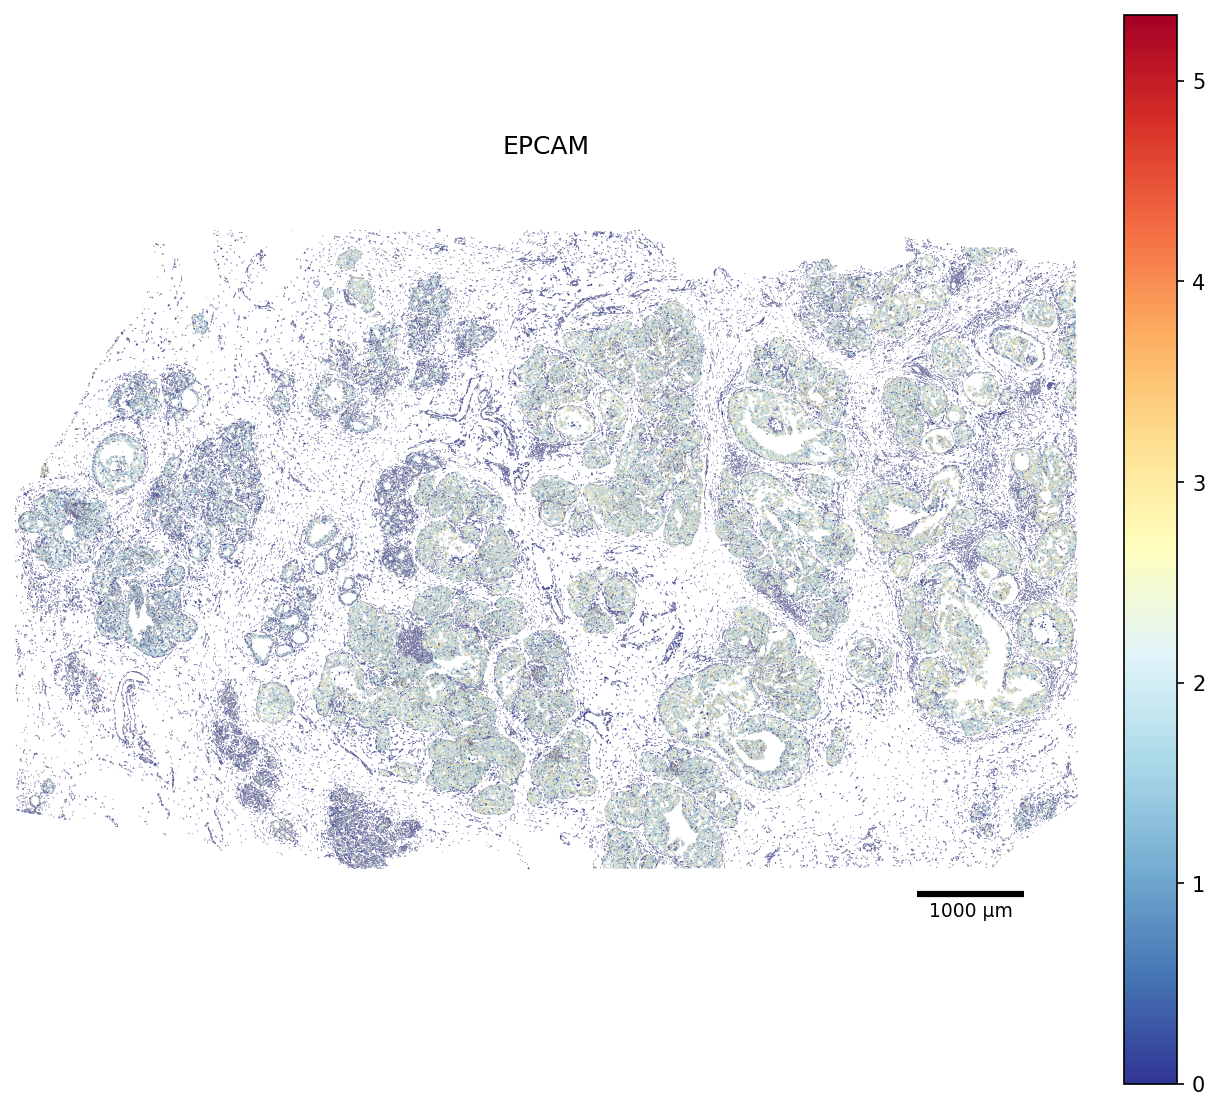

In [25]:
# Restrict the polygon dict to the scored cells (faster rendering)
seg_crop = {cid: seg[cid] for cid in adata.obs_names if cid in seg}

fig, ax = plot_segmentation(
    adata,
    segmentation=seg_crop,
    color_by='EPCAM',
    cmap='RdYlBu_r',
    figsize=None,
    scalebar_kwargs={'units': 'µm'},
)

Then, we plot one of the metabolic tasks that have previously been link to multiple cancers (cropped slide):

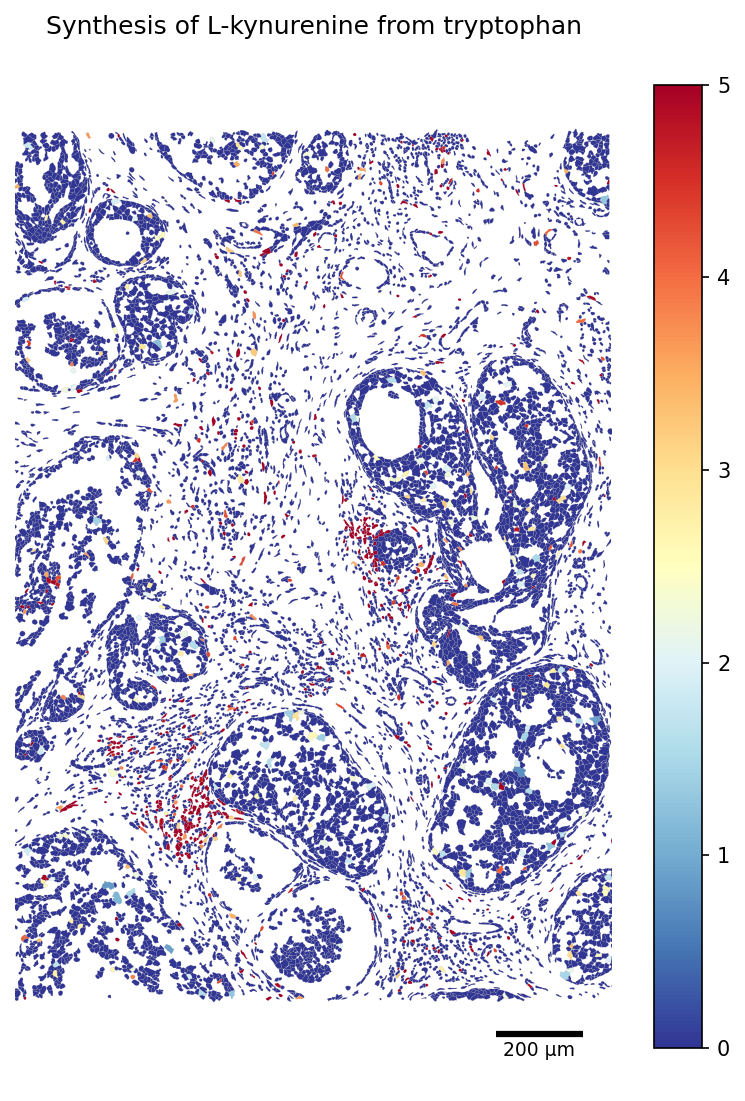

In [26]:
TASK = 'Synthesis of L-kynurenine from tryptophan'
# Restrict the polygon dict to the scored cells (faster rendering)
seg_crop = {cid: seg[cid] for cid in adata_scored.obs_names if cid in seg}

fig, ax = plot_segmentation(
    adata_scored.metabolic_tasks,
    segmentation=seg_crop,
    color_by=TASK,
    cmap='RdYlBu_r',
    figsize=(9, 9),
    vmax=5,
    scalebar_kwargs={'units': 'µm'},
)

Similarly, we visualize the production of lactate, a hallmark of multiple cancers:

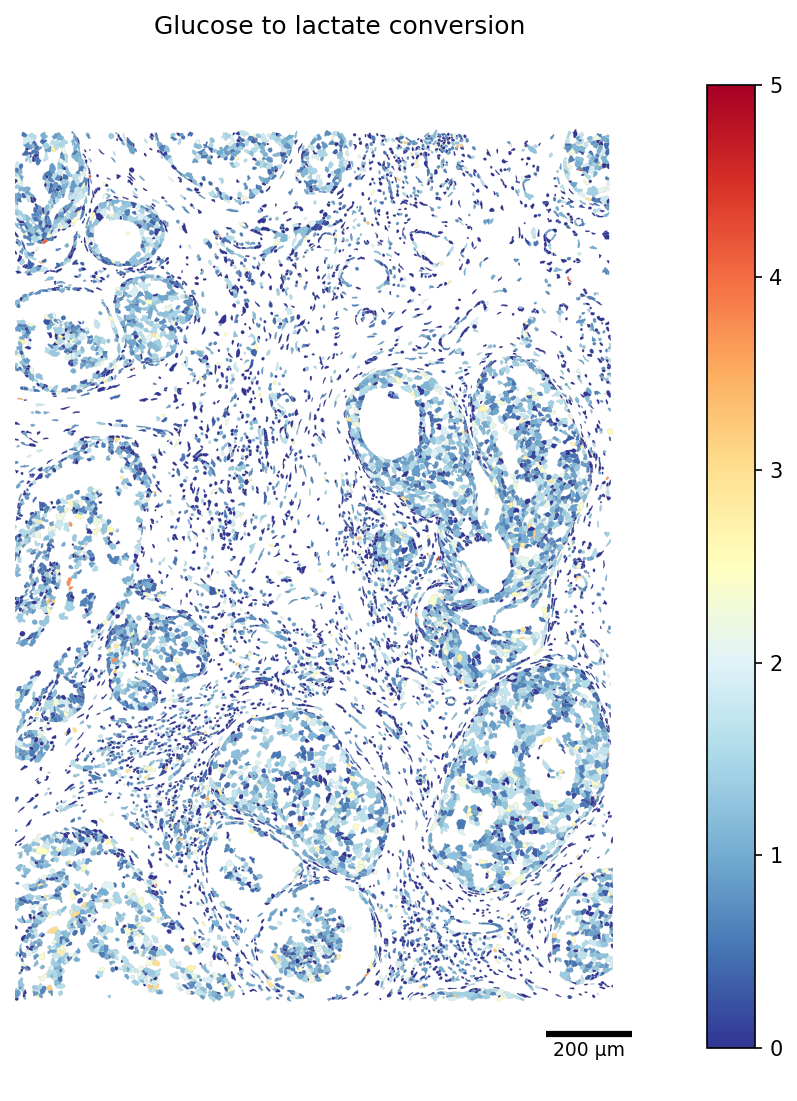

In [27]:
TASK = 'Glucose to lactate conversion'
# Restrict the polygon dict to the scored cells (faster rendering)
seg_crop = {cid: seg[cid] for cid in adata_scored.obs_names if cid in seg}

fig, ax = plot_segmentation(
    adata_scored.metabolic_tasks,
    segmentation=seg_crop,
    color_by=TASK,
    cmap='RdYlBu_r',
    crop=crop_window,
    figsize=(9, 9),
    vmax=5,
    scalebar_kwargs={'units': 'µm'},
)

the scCellFie function further supports the visualization of multiple tasks, where we can control the number of columns by modifying the parameter `ncols`.

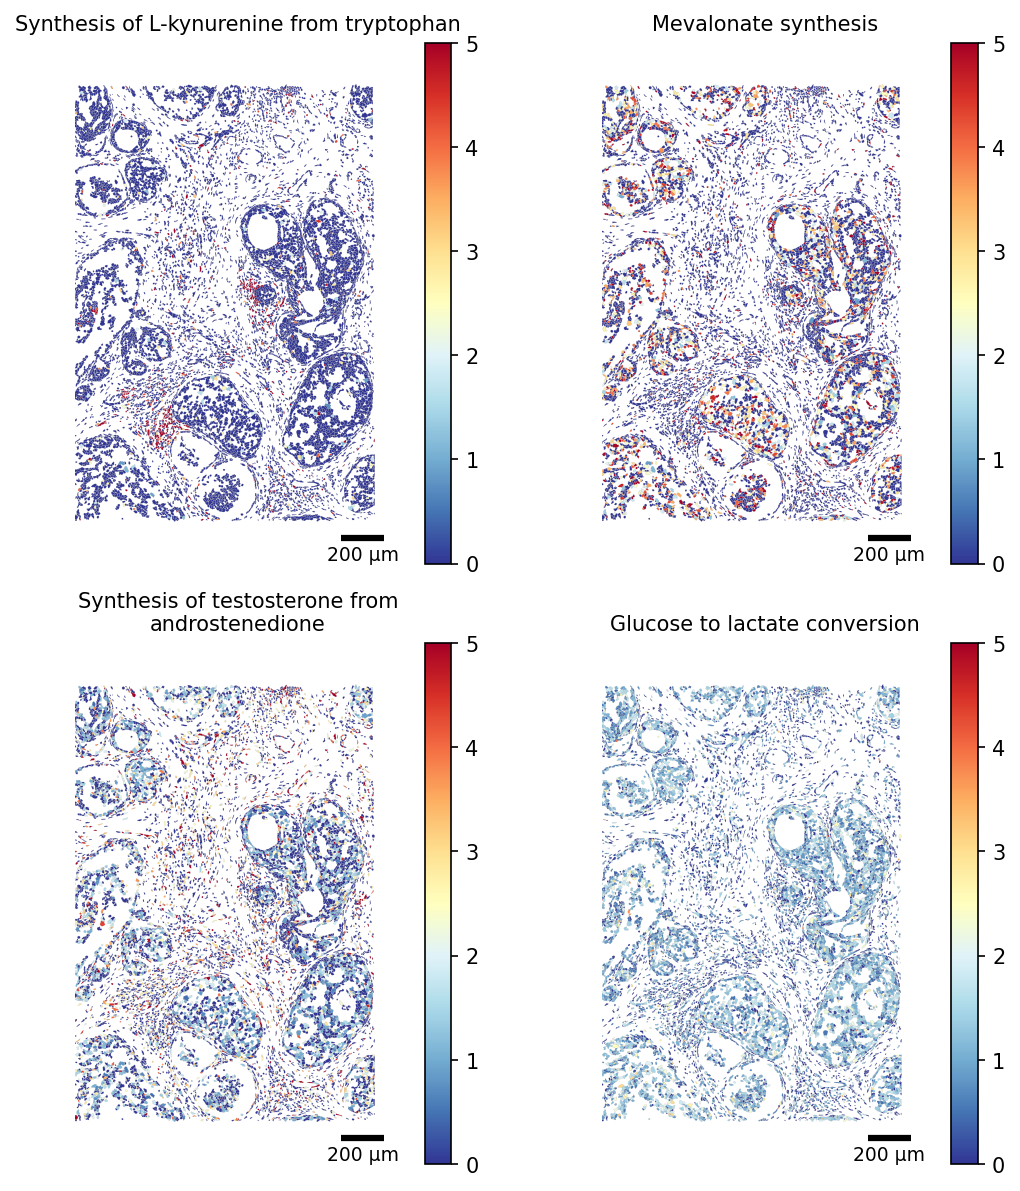

In [28]:
TASKS = ['Synthesis of L-kynurenine from tryptophan', 'Mevalonate synthesis',
         'Synthesis of testosterone from androstenedione', 'Glucose to lactate conversion']
# Restrict the polygon dict to the scored cells (faster rendering)
seg_crop = {cid: seg[cid] for cid in adata_scored.obs_names if cid in seg}

fig, ax = plot_segmentation(
    adata_scored.metabolic_tasks,
    segmentation=seg_crop,
    crop=(8500, 1500, 10000, 3500),
    color_by=TASKS,
    cmap='RdYlBu_r',
    figsize=(4,4),
    ncols=2,
    scalebar_kwargs={'units': 'µm'},
    vmax=5,
    title_fontsize=10,
)
